# Santander Customer Satisfaction Kaggle Challenge.

The goal is to predict whether a customer is unsatisfied using anonymized customer/banking features.

- TARGET = 0 means the customer is satisfied.
- TARGET = 1 means the customer is unsatisfied.


## 1. Import Libraries

In [1]:
# Importing the main libraries for this Kaggle challenge

import pandas as pd
import numpy as np

# These are used to split the data and evaluate the model
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, precision_score, recall_score, f1_score, accuracy_score

# These are used for preprocessing and machine learning models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier


# Matplotlib is used to create plots and visualizations
import matplotlib.pyplot as plt


## 2. Load the Dataset

Here I load the Kaggle files:

- train.csv is used to train and validate the model.
- test.csv is used to create the final Kaggle predictions.
- sample_submission.csv shows the correct format for the final submission file.


In [2]:
# Loading the datasets from the dataset folder

train = pd.read_csv("../dataset/train.csv")
test = pd.read_csv("../dataset/test.csv")
sample_submission = pd.read_csv("../dataset/sample_submission.csv")

# Print shapes to understand data size
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

# Preview data
train.head()

Train shape: (76020, 371)
Test shape: (75818, 370)
Sample submission shape: (75818, 2)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


## 3. Check the Target Column

The target column is what the model is trying to predict. This step is important because the Santander dataset is imbalanced.


Target counts:
TARGET
0    73012
1     3008
Name: count, dtype: int64

Target percentage:
TARGET
0    96.043147
1     3.956853
Name: proportion, dtype: float64


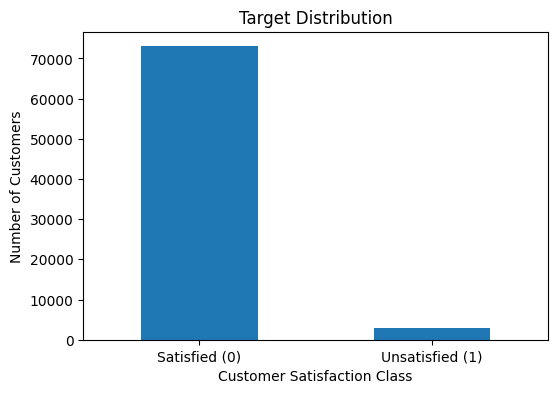


Since there are usually many more 0s than 1s, accuracy can be misleading.
A model could predict mostly 0 and still look accurate, but it may not find unsatisfied customers well.
That is why ROC-AUC is a better metric for this project.


In [3]:
# Checking the TARGET column
# TARGET = 0 means satisfied customer
# TARGET = 1 means unsatisfied customer

print("Target counts:")
print(train["TARGET"].value_counts())

# Checking the percentages makes the class imbalance easier to understand
print("\nTarget percentage:")
print(train["TARGET"].value_counts(normalize=True) * 100)

# Visualizing the target distribution
# This helps show the class imbalance in the dataset


target_counts = train["TARGET"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Customer Satisfaction Class")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Satisfied (0)", "Unsatisfied (1)"], rotation=0)

plt.show()

print()
print("Since there are usually many more 0s than 1s, accuracy can be misleading.\n"
      "A model could predict mostly 0 and still look accurate, but it may not find unsatisfied customers well.\n"
      "That is why ROC-AUC is a better metric for this project.")


## 4. Separate Features and Target

The ID column is only an identifier, so I remove it from the features.


In [4]:
# Saving the test IDs because they are needed later for the Kaggle submission file
test_ids = test["ID"]

# X contains only the training features
# y contains the target values
X = train.drop(columns=["ID", "TARGET"])
y = train["TARGET"]

# The test set does not have TARGET, so I only remove ID
X_test = test.drop(columns=["ID"])

print("Training feature shape:", X.shape)
print("Test feature shape:", X_test.shape)


Training feature shape: (76020, 369)
Test feature shape: (75818, 369)


## 5. Clean the Dataset

Some columns do not help the model because they are constant or duplicated. Removing these columns makes the dataset cleaner and training faster.


In [5]:
# Step 1: Remove constant columns
# A constant column has the same value for every row.
# Since it never changes, it cannot help the model separate satisfied and unsatisfied customers.

constant_cols = [col for col in X.columns if X[col].nunique() <= 1]

print("Constant columns removed:", len(constant_cols))

X = X.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)


# Step 2: Remove duplicate columns
# Duplicate columns repeat the exact same information.
# Keeping both does not add anything new to the model.

duplicate_cols = X.columns[X.T.duplicated()].tolist()

print("Duplicate columns removed:", len(duplicate_cols))

X = X.drop(columns=duplicate_cols)
X_test = X_test.drop(columns=duplicate_cols)


# Final shape after cleaning
print("Final feature shape after cleaning:", X.shape)

# This cleaning step helps reduce noise and avoids giving the model repeated or unecessary information.


Constant columns removed: 34
Duplicate columns removed: 29
Final feature shape after cleaning: (76020, 306)


## 6. Fix a Known Strange Value in var3

In this dataset, var3 sometimes has a strange value of -999999. I replace it with 2, which is commonly used as a normal value in this column.


In [6]:
# Fixing the unusual -999999 value in var3 if the column exists

if "var3" in X.columns:
    print("Number of -999999 values before fix:", (X["var3"] == -999999).sum())

    # Replacing -999999 with 2
    # This prevents the model from treating the strange value as a meaningful extreme number.
    X["var3"] = X["var3"].replace(-999999, 2)
    X_test["var3"] = X_test["var3"].replace(-999999, 2)

    print("Number of -999999 values after fix:", (X["var3"] == -999999).sum())
else:
    print("var3 column was not found, so no fix was needed.")


Number of -999999 values before fix: 116
Number of -999999 values after fix: 0


## 6. Feature Distribution Visualizations

The dataset has many numerical features, and many values are close to zero. These histograms help show how selected features are distributed after cleaning.

For the histograms, I used `density=True`, so the y-axis is scaled as density instead of raw count. This makes the plots easier to compare. I also limited the x-axis using percentiles so extreme values do not make the plot unreadable.

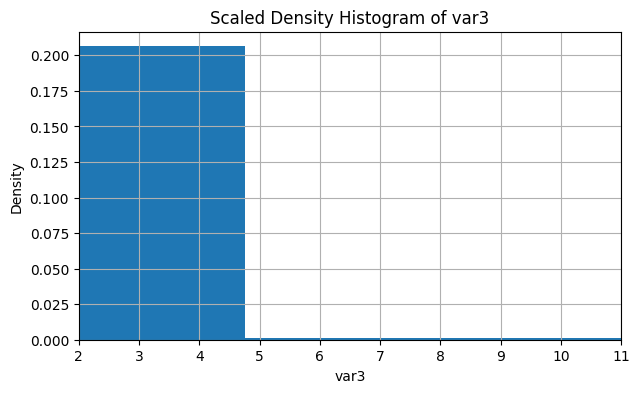

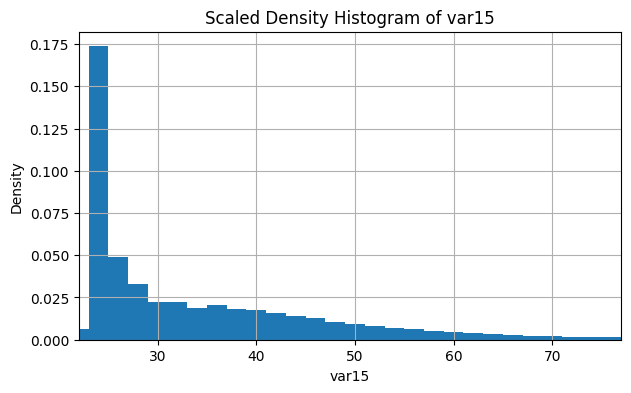

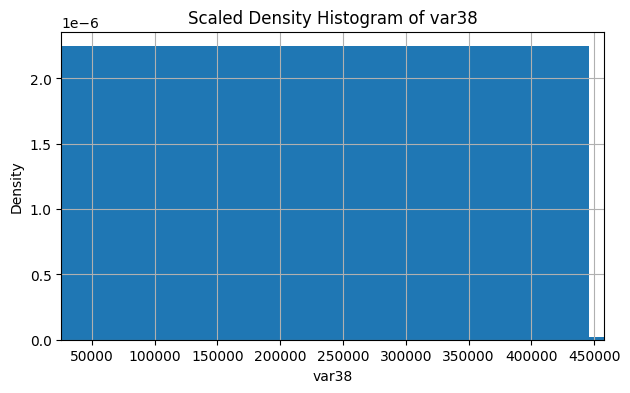

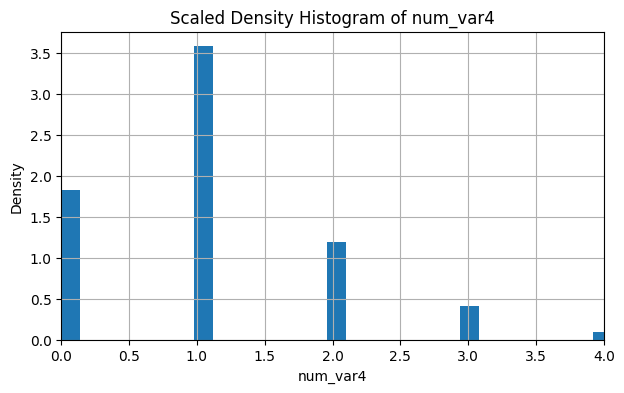

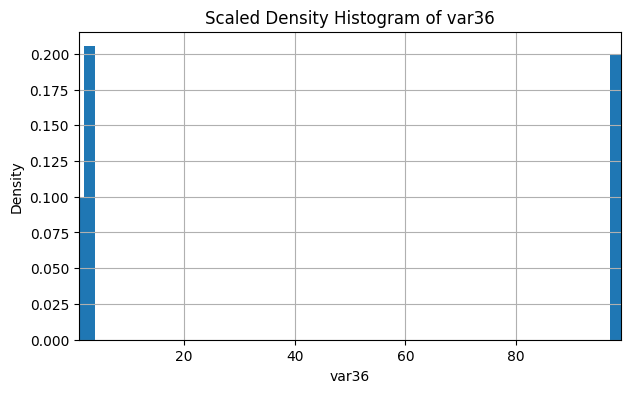

In [27]:
# Scaled density histograms for selected features
# density=True scales the y-axis so the total area of the histogram equals 1.
# The x-axis is limited between the 1st and 99th percentile to avoid extreme outliers making the plot too wide.

selected_features = [feature for feature in ["var3", "var15", "var38", "num_var4", "var36"] if feature in X.columns]

for feature in selected_features:
    lower_limit = X[feature].quantile(0.01)
    upper_limit = X[feature].quantile(0.99)
    
    plt.figure(figsize=(7, 4))
    plt.hist(X[feature], bins=50, density=True)
    
    plt.title(f"Scaled Density Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.xlim(lower_limit, upper_limit)
    plt.grid(True)
    
    plt.savefig(f"images/feature_dist_{feature}.png", bbox_inches="tight")
    plt.show()


## 7. Class-Based Density Histograms

These histograms compare selected features for satisfied and unsatisfied customers. Since the dataset is imbalanced, using density scaling is important because class 1 has far fewer rows than class 0.

This means the plot compares the shape of the distributions instead of only showing raw counts.

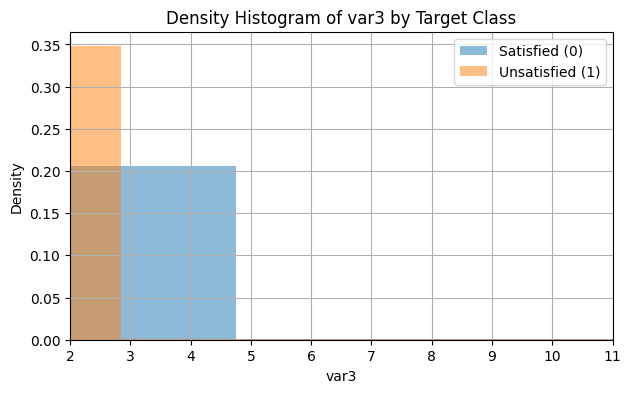

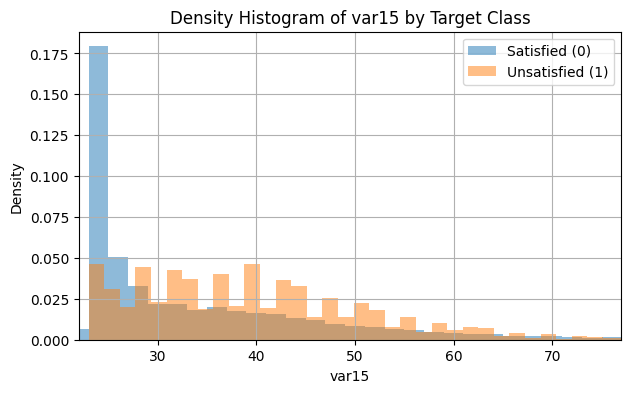

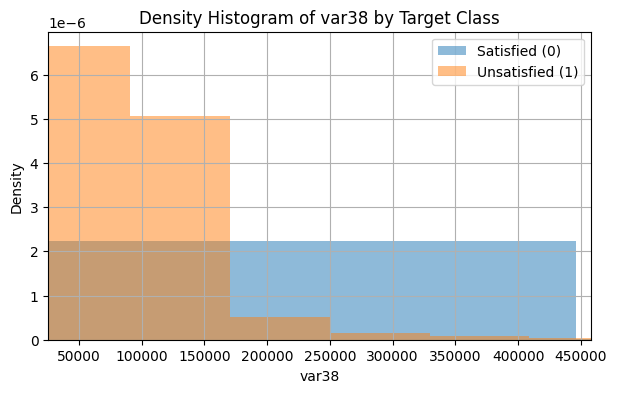

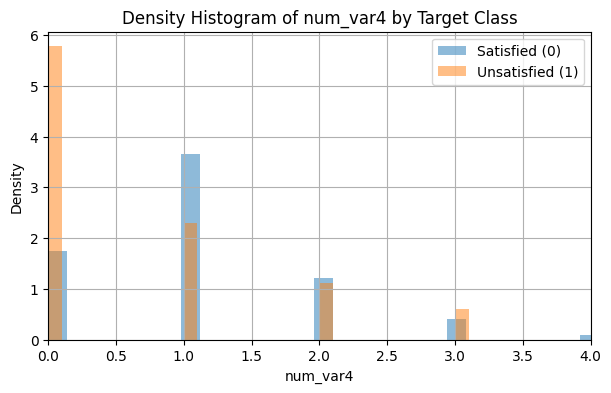

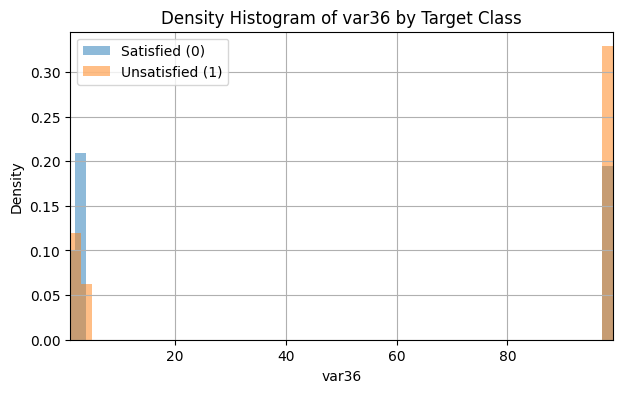

In [28]:
# Class-based density histograms
# This compares class 0 and class 1 fairly by using density=True.
# Without density scaling, the class 1 bars would be very small because there are fewer unsatisfied customers.

for feature in selected_features:
    lower_limit = X[feature].quantile(0.01)
    upper_limit = X[feature].quantile(0.99)
    
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        X[y == 0][feature],
        bins=50,
        density=True,
        alpha=0.5,
        label="Satisfied (0)"
    )
    
    plt.hist(
        X[y == 1][feature],
        bins=50,
        density=True,
        alpha=0.5,
        label="Unsatisfied (1)"
    )
    
    plt.title(f"Density Histogram of {feature} by Target Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.xlim(lower_limit, upper_limit)
    plt.legend()
    plt.grid(True)

    plt.savefig(f"images/class_density_{feature}.png", bbox_inches="tight")
    plt.show()


## 7. Train and Validation Split

I split the training data into training and validation sets. I use stratify=y so both sets keep a similar balance of satisfied and unsatisfied customers.


In [9]:
# Splitting the dataset into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target percentage:")
print(y_val.value_counts(normalize=True) * 100)


X_train shape: (60816, 306)
X_val shape: (15204, 306)

Training target percentage:
TARGET
0    96.043804
1     3.956196
Name: proportion, dtype: float64

Validation target percentage:
TARGET
0    96.040516
1     3.959484
Name: proportion, dtype: float64


## 8. Train and Compare Models

Train multiple models and compare them using ROC-AUC. Testing multiple models is useful because one model may handle this dataset better than another.


In [10]:
# Creating a dictionary of models to test
# Each model is given a readable name so the results are easier to compare.

models = {
    "Logistic Regression": Pipeline([
        # Logistic Regression works better when features are scaled.
        # StandardScaler puts features on a similar scale.
        ("scaler", StandardScaler()),

        # class_weight="balanced" helps because the dataset has fewer unsatisfied customers.
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        # More trees usually make the forest more stable.
        n_estimators=200,

        # Limiting depth helps avoid overfitting.
        max_depth=8,

        # This makes each leaf have enough samples, which also helps reduce overfitting.
        min_samples_leaf=10,

        # This helps the model pay more attention to the minority class.
        class_weight="balanced_subsample",

        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        # Extra Trees is similar to Random Forest, but it adds more randomness.
        # Sometimes this helps with tabular data.
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        # Gradient boosting builds trees step by step and improves over time.
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

# These lists/dictionaries will store the results and trained models
results = []
trained_models = {}

# Train each model and evaluate it
for name, model in models.items():
    print("Training:", name)

    # Fit the model using the training set
    model.fit(X_train, y_train)

    # Predict probabilities for the validation set
    # We need probabilities instead of 0/1 labels for ROC-AUC.
    val_probs = model.predict_proba(X_val)[:, 1]

    # Calculate ROC-AUC score
    auc = roc_auc_score(y_val, val_probs)

    # Save the model result
    results.append({
        "Model": name,
        "Validation ROC-AUC": auc
    })

    # Save the trained model so we can use the best one later
    trained_models[name] = model

    print(name, "ROC-AUC:", round(auc, 5))
    print()

# Convert results into a DataFrame and sort from best to worst
results_df = pd.DataFrame(results).sort_values(by="Validation ROC-AUC", ascending=False)

results_df


Training: Logistic Regression
Logistic Regression ROC-AUC: 0.80315

Training: Random Forest
Random Forest ROC-AUC: 0.82082

Training: Extra Trees
Extra Trees ROC-AUC: 0.78971

Training: Hist Gradient Boosting
Hist Gradient Boosting ROC-AUC: 0.84735



,Model,Validation ROC-AUC
3,Hist Gradient Boosting,0.847352
1,Random Forest,0.820818
0,Logistic Regression,0.803148
2,Extra Trees,0.789711


## 9. Evaluate the Best Model

Here I select the model with the highest validation ROC-AUC score. Kaggle uses probabilities for the final score, but I also show classification report to better understand the model.


Best model: Hist Gradient Boosting
Best ROC-AUC: 0.8473522946158106

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14602
           1       0.20      0.00      0.00       602

    accuracy                           0.96     15204
   macro avg       0.58      0.50      0.49     15204
weighted avg       0.93      0.96      0.94     15204



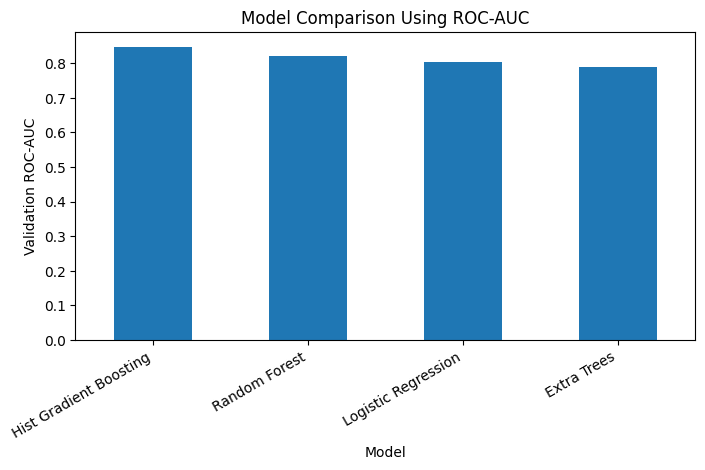

In [11]:
# Selecting the model with the best ROC-AUC score
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Best ROC-AUC:", results_df.iloc[0]["Validation ROC-AUC"])

# Predicting probabilities on the validation set
val_probs = best_model.predict_proba(X_val)[:, 1]

# Turning probabilities into 0/1 predictions (only for understanding)
val_preds = (val_probs >= 0.50).astype(int)

# Showing classification report
print("\nClassification Report:")
print(classification_report(y_val, val_preds))

# Visualizing model performance using ROC-AUC scores
# Higher ROC-AUC means the model is better at separating the two classes

plt.figure(figsize=(8, 4))

model_scores = results_df.set_index("Model")["Validation ROC-AUC"]
model_scores.plot(kind="bar")

plt.title("Model Comparison Using ROC-AUC")
plt.xlabel("Model")
plt.ylabel("Validation ROC-AUC")
plt.xticks(rotation=30, ha="right")

plt.show()

## ROC Curve for Best Model

This ROC curve shows how well the best model separates satisfied and unsatisfied customers.  
The dashed line represents random guessing, while a curve closer to the top-left corner means stronger performance.

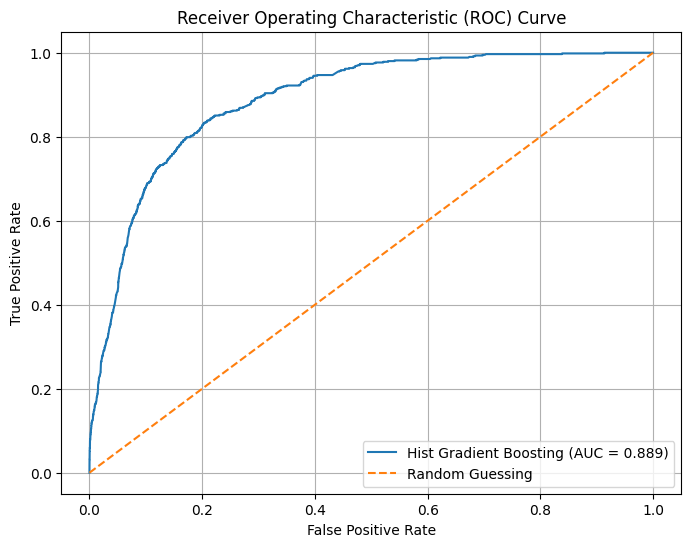

In [29]:
# Creating an ROC curve for the best model
# This helps visualize how well the model separates class 0 and class 1

from sklearn.metrics import roc_curve, auc

# Select the best model from the results table
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

# Get prediction probabilities for the validation set
# We use probabilities for class 1 because ROC-AUC is based on ranking probabilities
val_probs = best_model.predict_proba(X_val)[:, 1]

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_val, val_probs)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})")

# This dashed line shows random guessing
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")

plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.savefig("images/roc_curve.png", bbox_inches="tight")
plt.show()

## Threshold Tuning for Minority Class Recall

The dataset is highly imbalanced, so the default probability threshold of `0.50` can cause the model to predict almost every customer as satisfied. This gives high accuracy, but the recall for the minority class can be very low.

To address this, I tested multiple thresholds and compared accuracy, precision, recall, and F1-score for class 1. Lowering the threshold usually improves recall because the model becomes more willing to predict the minority class.

In [12]:
# Testing different decision thresholds to improve recall for the minority class
# The default threshold is 0.50, but that can be too strict for an imbalanced dataset.

threshold_results = []

for threshold in np.arange(0.01, 0.51, 0.01):
    # Convert probabilities into 0/1 predictions using the current threshold
    val_preds_threshold = (val_probs >= threshold).astype(int)
    
    # Store the evaluation metrics for class 1
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, val_preds_threshold),
        "Precision_Class_1": precision_score(y_val, val_preds_threshold, zero_division=0),
        "Recall_Class_1": recall_score(y_val, val_preds_threshold, zero_division=0),
        "F1_Class_1": f1_score(y_val, val_preds_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

# Showing the thresholds with the best F1 scores for the minority class
threshold_df.sort_values(by="F1_Class_1", ascending=False).head(10)


,Threshold,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
13,0.14,0.905946,0.213296,0.511628,0.301075
12,0.13,0.902920,0.208667,0.519934,0.297812
14,0.15,0.911997,0.216049,0.465116,0.295047
15,0.16,0.919166,0.225241,0.426910,0.294894
11,0.12,0.899829,0.204239,0.528239,0.294581
10,0.11,0.892068,0.192422,0.539867,0.283719
9,0.10,0.885556,0.186329,0.561462,0.279801
16,0.17,0.922520,0.218200,0.370432,0.274631
8,0.09,0.877730,0.178845,0.581395,0.273544
7,0.08,0.865562,0.169569,0.614618,0.265805


## Threshold Tuning Visualization

This plot shows the tradeoff between precision and recall for the minority class. Improving recall usually means the model finds more unsatisfied customers, but it may also create more false positives.

This helps explain why the model is not fully captured by accuracy alone.

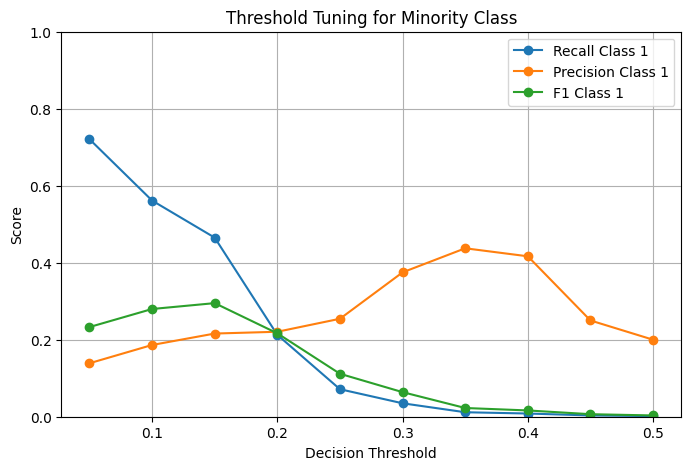

In [30]:
# Plotting precision, recall, and F1-score for class 1 across different thresholds

plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Recall_Class_1"], marker="o", label="Recall Class 1")
plt.plot(threshold_df["Threshold"], threshold_df["Precision_Class_1"], marker="o", label="Precision Class 1")
plt.plot(threshold_df["Threshold"], threshold_df["F1_Class_1"], marker="o", label="F1 Class 1")

plt.title("Threshold Tuning for Minority Class")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.savefig("images/threshold_tuning.png", bbox_inches="tight")
plt.show()


## Classification Report After Threshold Tuning

After testing thresholds, I selected the threshold with the best F1-score for class 1. This gives a better balance between finding unsatisfied customers and avoiding too many false positives.

This tuned threshold is used only for validation analysis. The Kaggle submission still uses probability values because Kaggle expects probabilities for `TARGET`.

In [20]:
# Choosing the threshold with the best F1-score for the minority class
best_threshold = threshold_df.sort_values(by="F1_Class_1", ascending=False).iloc[0]["Threshold"]

print("Best threshold based on F1-score for class 1:", round(best_threshold, 2))

final_val_preds = (val_probs >= best_threshold).astype(int)

print("\nClassification Report with Tuned Threshold:")
print(classification_report(y_val, final_val_preds))

Best threshold based on F1-score for class 1: 0.15

Classification Report with Tuned Threshold:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     14602
           1       0.22      0.47      0.30       602

    accuracy                           0.91     15204
   macro avg       0.60      0.70      0.62     15204
weighted avg       0.95      0.91      0.93     15204



## 10. Train Final Model and Create Submission File

After choosing the best model, I train it again using the full training dataset. This gives the model as much training data as possible before making predictions on the test file.


The tuned threshold is used only to explain validation performance and minority class recall. The final Kaggle submission still uses probability values because Kaggle expects probabilities in the `TARGET` column.


In [15]:
# Training the best model again using all available training data

best_model.fit(X, y)

# Predicting probabilities for the Kaggle test set
# These probabilities are what Kaggle expects in the TARGET column.
test_probs = best_model.predict_proba(X_test)[:, 1]

# Creating the final submission DataFrame in Kaggle's required format
submission = pd.DataFrame({
    "ID": test_ids,
    "TARGET": test_probs
})

# Saving the submission file
submission.to_csv("../santander_submission.csv", index=False)

print("Submission file created successfully: santander_submission.csv")

# Preview the first few rows
submission.head()


Submission file created successfully: santander_submission.csv


,ID,TARGET
0,2,0.041837
1,5,0.049544
2,6,0.001867
3,7,0.012195
4,9,0.002041
